In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import  seaborn as  sns
import sklearn 
from sklearn.model_selection import train_test1_split
from sklearn.metrics import d2_absolute_error_score ,mean_squared_error,f1_score

In [129]:
data1=pd.read_excel(r"C:\Users\vombravalli shankar\Downloads\archive (2)\Data_Train.xlsx")

In [130]:
data1.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [131]:
data1.shape

(10683, 11)

In [132]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [133]:
data1.isna().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [134]:
data1["Route"].fillna(method="ffill",inplace=True)

In [135]:
data1["Total_Stops"]=data1["Total_Stops"].fillna(data1["Total_Stops"].mode().iloc[0])

In [136]:
data1["Journey_day"]=pd.to_datetime(data1["Date_of_Journey"]).dt.day
data1["Journey_months"]=pd.to_datetime(data1["Date_of_Journey"]).dt.month

C:\Users\vombravalli shankar\AppData\Local\Temp\ipykernel_5056\2132050485.py:1: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  data1["Journey_day"]=pd.to_datetime(data1["Date_of_Journey"]).dt.day
C:\Users\vombravalli shankar\AppData\Local\Temp\ipykernel_5056\2132050485.py:2: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  data1["Journey_months"]=pd.to_datetime(data1["Date_of_Journey"]).dt.month


In [137]:
data1.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_months
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,5,1
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,6,9
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,5,12
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,3,1


In [138]:
data1.drop(["Date_of_Journey","Additional_Info"],axis=1,inplace=True)

In [139]:
data1["Arrival_hour"]=pd.to_datetime(data1["Arrival_Time"]).dt.hour
data1["Arrival_minute"]=pd.to_datetime(data1["Arrival_Time"]).dt.minute
data1["Dep_hour"]=pd.to_datetime(data1["Dep_Time"]).dt.hour
data1["Dep_minute"]=pd.to_datetime(data1["Dep_Time"]).dt.minute
data1.drop(["Arrival_Time","Dep_Time"],axis=1,inplace=True)

In [140]:
data1["Duration"].value_counts

<bound method IndexOpsMixin.value_counts of 0        2h 50m
1        7h 25m
2           19h
3        5h 25m
4        4h 45m
          ...  
10678    2h 30m
10679    2h 35m
10680        3h
10681    2h 40m
10682    8h 20m
Name: Duration, Length: 10683, dtype: object>

In [141]:
def convert_to_minutes(duration):
    hours = 0
    minutes = 0
    
    # Check for hours in the string and convert to minutes
    if 'h' in duration:
        hours = int(duration.split('h')[0].strip())
        duration = duration.split('h')[1]
    
    # Check for minutes in the string
    if 'm' in duration:
        minutes = int(duration.split('m')[0].strip())
    
    # Total time in minutes
    total_minutes = hours * 60 + minutes
    return total_minutes

# Apply the function to the Duration column
data1['Total_Minutes'] = data1['Duration'].apply(convert_to_minutes)

In [142]:
data1.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Price,Journey_day,Journey_months,Arrival_hour,Arrival_minute,Dep_hour,Dep_minute,Total_Minutes
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,3897,24,3,1,10,22,20,170
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,7662,5,1,13,15,5,50,445
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,13882,6,9,4,25,9,25,1140
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,6218,5,12,23,30,18,5,325
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,13302,3,1,21,35,16,50,285


In [143]:
def split_duration(duration):
    hours = 0
    minutes = 0
    
    # Extract hours if present
    if 'h' in duration:
        hours = int(duration.split('h')[0].strip())
        duration = duration.split('h')[1]
    
    # Extract minutes if present
    if 'm' in duration:
        minutes = int(duration.split('m')[0].strip())
    
    return hours, minutes

# Apply the function and create new columns for hours and minutes
data1[['Hours', 'Minutes']] = data1['Duration'].apply(lambda x: pd.Series(split_duration(x)))


In [144]:
data1.drop(["Duration","Total_Minutes"],axis=1,inplace=True)

In [145]:
data1.head()

,Airline,Source,Destination,Route,Total_Stops,Price,Journey_day,Journey_months,Arrival_hour,Arrival_minute,Dep_hour,Dep_minute,Hours,Minutes
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,3897,24,3,1,10,22,20,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,7662,5,1,13,15,5,50,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,13882,6,9,4,25,9,25,19,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,6218,5,12,23,30,18,5,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,13302,3,1,21,35,16,50,4,45


In [146]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Airline         10683 non-null  object
 1   Source          10683 non-null  object
 2   Destination     10683 non-null  object
 3   Route           10683 non-null  object
 4   Total_Stops     10683 non-null  object
 5   Price           10683 non-null  int64 
 6   Journey_day     10683 non-null  int64 
 7   Journey_months  10683 non-null  int64 
 8   Arrival_hour    10683 non-null  int64 
 9   Arrival_minute  10683 non-null  int64 
 10  Dep_hour        10683 non-null  int64 
 11  Dep_minute      10683 non-null  int64 
 12  Hours           10683 non-null  int64 
 13  Minutes         10683 non-null  int64 
dtypes: int64(9), object(5)
memory usage: 1.1+ MB


In [147]:
airline=data1["Airline"].value_counts()


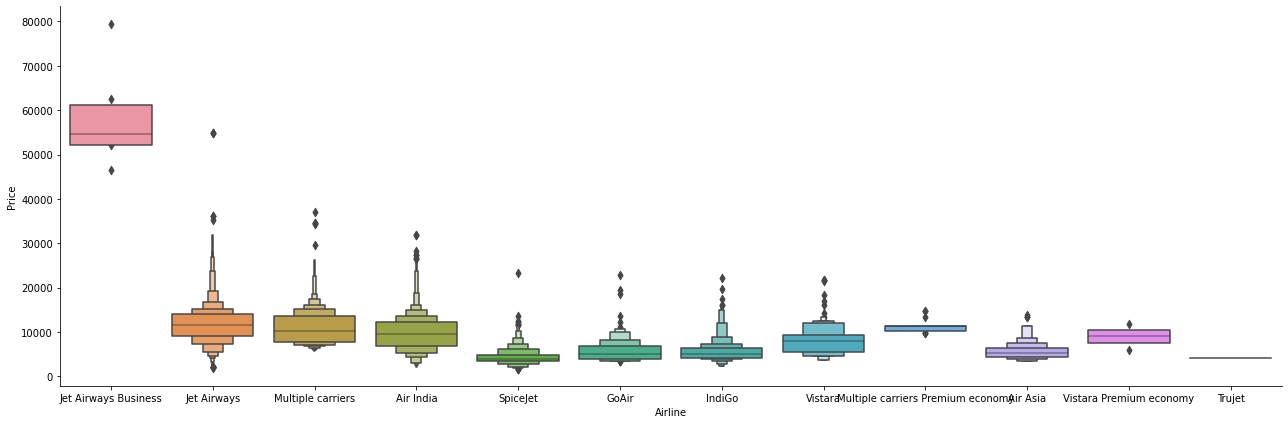

In [148]:
sns.catplot(y="Price",x="Airline",data=data1.sort_values("Price",ascending=False),kind="boxen",height=6,aspect=3)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

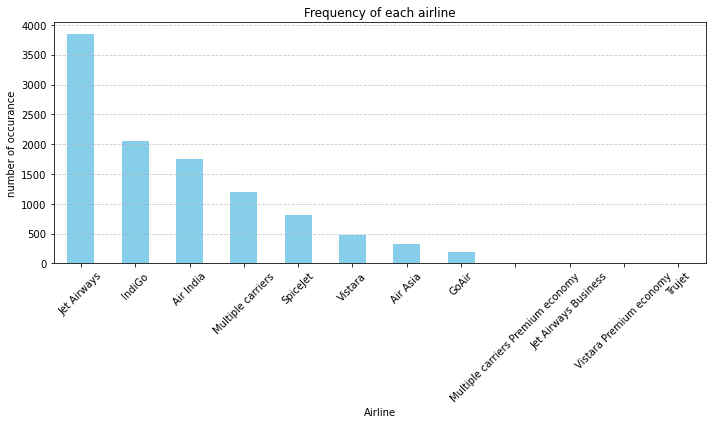

In [149]:
plt.figure(figsize=(10,6))
airline.plot(kind="bar",color="skyblue")
plt.title("Frequency of each airline")
plt.xlabel("Airline")
plt.ylabel("number of occurance")
plt.xticks(rotation=45)
plt.grid(axis="y",linestyle="--",alpha=0.7)
plt.tight_layout()
plt.show

In [150]:
Airline=data1["Airline"]
Airline=pd.get_dummies(Airline,drop_first=True)
Airline.head()

,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy
0,0,0,1,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,1,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,0


In [151]:
Airline.shape

(10683, 11)

In [152]:
source=data1["Source"].value_counts()

<function matplotlib.pyplot.show(close=None, block=None)>

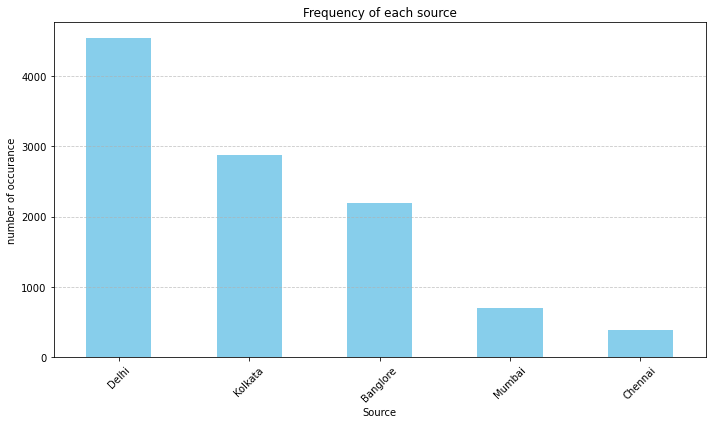

In [153]:
plt.figure(figsize=(10,6))
source.plot(kind="bar",color="skyblue")
plt.title("Frequency of each source")
plt.xlabel("Source")
plt.ylabel("number of occurance")
plt.xticks(rotation=45)
plt.grid(axis="y",linestyle="--",alpha=0.7)
plt.tight_layout()
plt.show




In [154]:
Source=data1["Source"]
Source=pd.get_dummies(Source,drop_first=True)
Source.head()

,Chennai,Delhi,Kolkata,Mumbai
0,0,0,0,0
1,0,0,1,0
2,0,1,0,0
3,0,0,1,0
4,0,0,0,0


In [155]:
data1.head()

,Airline,Source,Destination,Route,Total_Stops,Price,Journey_day,Journey_months,Arrival_hour,Arrival_minute,Dep_hour,Dep_minute,Hours,Minutes
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,3897,24,3,1,10,22,20,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,7662,5,1,13,15,5,50,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,13882,6,9,4,25,9,25,19,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,6218,5,12,23,30,18,5,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,13302,3,1,21,35,16,50,4,45


In [156]:
destination=data1["Destination"].value_counts()

<function matplotlib.pyplot.show(close=None, block=None)>

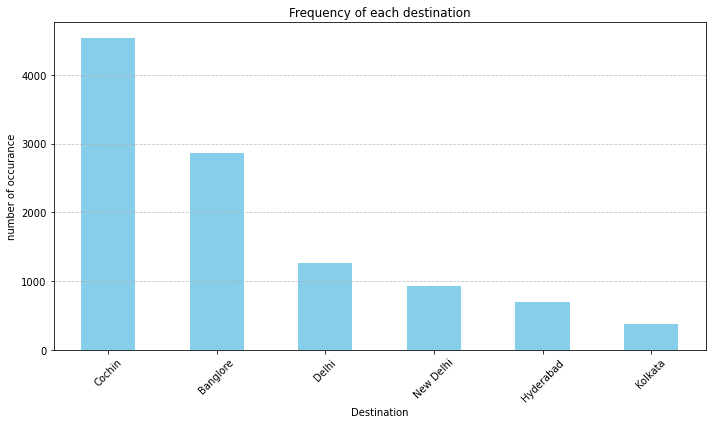

In [157]:
plt.figure(figsize=(10,6))
destination.plot(kind="bar",color="skyblue")
plt.title("Frequency of each destination")
plt.xlabel("Destination")
plt.ylabel("number of occurance")
plt.xticks(rotation=45)
plt.grid(axis="y",linestyle="--",alpha=0.7)
plt.tight_layout()
plt.show

In [158]:
destination=data1["Destination"]
destination=pd.get_dummies(destination,drop_first=True)
destination.head()

,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
0,0,0,0,0,1
1,0,0,0,0,0
2,1,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,1


In [159]:
data1["Route"].head()

0                BLR → DEL
1    CCU → IXR → BBI → BLR
2    DEL → LKO → BOM → COK
3          CCU → NAG → BLR
4          BLR → NAG → DEL
Name: Route, dtype: object

In [160]:
data1.drop(["Route"],axis=1,inplace=True)

In [161]:
data1["Total_Stops"].value_counts()

1 stop      5626
non-stop    3491
2 stops     1520
3 stops       45
4 stops        1
Name: Total_Stops, dtype: int64

In [162]:
data1.replace({"non-stop":0,"1 stop":1,"2 stops":2,"3 stops":3,"4 stops":4},inplace=True)

In [163]:
data1.head()

,Airline,Source,Destination,Total_Stops,Price,Journey_day,Journey_months,Arrival_hour,Arrival_minute,Dep_hour,Dep_minute,Hours,Minutes
0,IndiGo,Banglore,New Delhi,0,3897,24,3,1,10,22,20,2,50
1,Air India,Kolkata,Banglore,2,7662,5,1,13,15,5,50,7,25
2,Jet Airways,Delhi,Cochin,2,13882,6,9,4,25,9,25,19,0
3,IndiGo,Kolkata,Banglore,1,6218,5,12,23,30,18,5,5,25
4,IndiGo,Banglore,New Delhi,1,13302,3,1,21,35,16,50,4,45


In [167]:
data_train=pd.concat([data1,Airline,Source,destination],axis=1)

In [168]:
data_train.head()

,Airline,Source,Destination,Total_Stops,Price,Journey_day,Journey_months,Arrival_hour,Arrival_minute,Dep_hour,...,Vistara Premium economy,Chennai,Delhi,Kolkata,Mumbai,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
0,IndiGo,Banglore,New Delhi,0,3897,24,3,1,10,22,...,0,0,0,0,0,0,0,0,0,1
1,Air India,Kolkata,Banglore,2,7662,5,1,13,15,5,...,0,0,0,1,0,0,0,0,0,0
2,Jet Airways,Delhi,Cochin,2,13882,6,9,4,25,9,...,0,0,1,0,0,1,0,0,0,0
3,IndiGo,Kolkata,Banglore,1,6218,5,12,23,30,18,...,0,0,0,1,0,0,0,0,0,0
4,IndiGo,Banglore,New Delhi,1,13302,3,1,21,35,16,...,0,0,0,0,0,0,0,0,0,1


In [169]:
data_train.columns

Index(['Airline', 'Source', 'Destination', 'Total_Stops', 'Price',
       'Journey_day', 'Journey_months', 'Arrival_hour', 'Arrival_minute',
       'Dep_hour', 'Dep_minute', 'Hours', 'Minutes', 'Air India', 'GoAir',
       'IndiGo', 'Jet Airways', 'Jet Airways Business', 'Multiple carriers',
       'Multiple carriers Premium economy', 'SpiceJet', 'Trujet', 'Vistara',
       'Vistara Premium economy', 'Chennai', 'Delhi', 'Kolkata', 'Mumbai',
       'Cochin', 'Delhi', 'Hyderabad', 'Kolkata', 'New Delhi'],
      dtype='object')

In [166]:
data1.head()

,Airline,Source,Destination,Total_Stops,Price,Journey_day,Journey_months,Arrival_hour,Arrival_minute,Dep_hour,Dep_minute,Hours,Minutes
0,IndiGo,Banglore,New Delhi,0,3897,24,3,1,10,22,20,2,50
1,Air India,Kolkata,Banglore,2,7662,5,1,13,15,5,50,7,25
2,Jet Airways,Delhi,Cochin,2,13882,6,9,4,25,9,25,19,0
3,IndiGo,Kolkata,Banglore,1,6218,5,12,23,30,18,5,5,25
4,IndiGo,Banglore,New Delhi,1,13302,3,1,21,35,16,50,4,45


In [170]:
data_train.drop(["Airline","Source","Destination"],axis=1,inplace=True)

In [171]:
data_train.head()

,Total_Stops,Price,Journey_day,Journey_months,Arrival_hour,Arrival_minute,Dep_hour,Dep_minute,Hours,Minutes,...,Vistara Premium economy,Chennai,Delhi,Kolkata,Mumbai,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
0,0,3897,24,3,1,10,22,20,2,50,...,0,0,0,0,0,0,0,0,0,1
1,2,7662,5,1,13,15,5,50,7,25,...,0,0,0,1,0,0,0,0,0,0
2,2,13882,6,9,4,25,9,25,19,0,...,0,0,1,0,0,1,0,0,0,0
3,1,6218,5,12,23,30,18,5,5,25,...,0,0,0,1,0,0,0,0,0,0
4,1,13302,3,1,21,35,16,50,4,45,...,0,0,0,0,0,0,0,0,0,1


In [172]:
data_train.shape

(10683, 30)

In [173]:
data_train.isna().sum()

Total_Stops                          0
Price                                0
Journey_day                          0
Journey_months                       0
Arrival_hour                         0
Arrival_minute                       0
Dep_hour                             0
Dep_minute                           0
Hours                                0
Minutes                              0
Air India                            0
GoAir                                0
IndiGo                               0
Jet Airways                          0
Jet Airways Business                 0
Multiple carriers                    0
Multiple carriers Premium economy    0
SpiceJet                             0
Trujet                               0
Vistara                              0
Vistara Premium economy              0
Chennai                              0
Delhi                                0
Kolkata                              0
Mumbai                               0
Cochin                   

In [174]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Total_Stops                        10683 non-null  int64
 1   Price                              10683 non-null  int64
 2   Journey_day                        10683 non-null  int64
 3   Journey_months                     10683 non-null  int64
 4   Arrival_hour                       10683 non-null  int64
 5   Arrival_minute                     10683 non-null  int64
 6   Dep_hour                           10683 non-null  int64
 7   Dep_minute                         10683 non-null  int64
 8   Hours                              10683 non-null  int64
 9   Minutes                            10683 non-null  int64
 10  Air India                          10683 non-null  uint8
 11  GoAir                              10683 non-null  uint8
 12  IndiGo            

In [176]:
test11=pd.read_excel(r"C:\Users\vombravalli shankar\Downloads\archive (2)\test1_set.xlsx")

In [177]:
test11.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
0,Jet Airways,6/06/2019,Delhi,Cochin,DEL → BOM → COK,17:30,04:25 07 Jun,10h 55m,1 stop,No info
1,IndiGo,12/05/2019,Kolkata,Banglore,CCU → MAA → BLR,06:20,10:20,4h,1 stop,No info
2,Jet Airways,21/05/2019,Delhi,Cochin,DEL → BOM → COK,19:15,19:00 22 May,23h 45m,1 stop,In-flight meal not included
3,Multiple carriers,21/05/2019,Delhi,Cochin,DEL → BOM → COK,08:00,21:00,13h,1 stop,No info
4,Air Asia,24/06/2019,Banglore,Delhi,BLR → DEL,23:55,02:45 25 Jun,2h 50m,non-stop,No info


In [178]:
test11.isna().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
dtype: int64

In [179]:
test1["Journey_day"]=pd.to_datetime(test1["Date_of_Journey"]).dt.day
test1["Journey_months"]=pd.to_datetime(test1["Date_of_Journey"]).dt.month
test1["Arrival_hour"]=pd.to_datetime(test1["Arrival_Time"]).dt.hour
test1["Arrival_minute"]=pd.to_datetime(test1["Arrival_Time"]).dt.minute
test1["Dep_hour"]=pd.to_datetime(test1["Dep_Time"]).dt.hour
test1["Dep_minute"]=pd.to_datetime(test1["Dep_Time"]).dt.minute


def convert_to_minutes(duration):
    hours = 0
    minutes = 0
    
    # Check for hours in the string and convert to minutes
    if 'h' in duration:
        hours = int(duration.split('h')[0].strip())
        duration = duration.split('h')[1]
    
    # Check for minutes in the string
    if 'm' in duration:
        minutes = int(duration.split('m')[0].strip())
    
    # Total time in minutes
    total_minutes = hours * 60 + minutes
    return total_minutes

# Apply the function to the Duration column
test1['Total_Minutes'] = test1['Duration'].apply(convert_to_minutes)

test1.drop(["Date_of_Journey","Arrival_Time","Dep_Time","Additional_Info","Duration"],axis=1,inplace=True)

C:\Users\vombravalli shankar\AppData\Local\Temp\ipykernel_5056\3054457431.py:1: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  test["Journey_day"]=pd.to_datetime(test["Date_of_Journey"]).dt.day
C:\Users\vombravalli shankar\AppData\Local\Temp\ipykernel_5056\3054457431.py:2: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  test["Journey_months"]=pd.to_datetime(test["Date_of_Journey"]).dt.month


In [180]:
test1.head()

,Airline,Source,Destination,Route,Total_Stops,Journey_day,Journey_months,Arrival_hour,Arrival_minute,Dep_hour,Dep_minute,Total_Minutes
0,Jet Airways,Delhi,Cochin,DEL → BOM → COK,1 stop,6,6,4,25,17,30,655
1,IndiGo,Kolkata,Banglore,CCU → MAA → BLR,1 stop,5,12,10,20,6,20,240
2,Jet Airways,Delhi,Cochin,DEL → BOM → COK,1 stop,21,5,19,0,19,15,1425
3,Multiple carriers,Delhi,Cochin,DEL → BOM → COK,1 stop,21,5,21,0,8,0,780
4,Air Asia,Banglore,Delhi,BLR → DEL,non-stop,24,6,2,45,23,55,170


In [181]:
def split_duration(duration):
    hours = 0
    minutes = 0
    
    # Extract hours if present
    if 'h' in duration:
        hours = int(duration.split('h')[0].strip())
        duration = duration.split('h')[1]
    
    # Extract minutes if present
    if 'm' in duration:
        minutes = int(duration.split('m')[0].strip())
    
    return hours, minutes

# Apply the function and create new columns for hours and minutes
data1[['Hours', 'Minutes']] = data1['Duration'].apply(lambda x: pd.Series(split_duration(x)))

KeyError: 'Duration'